## Machine Learning Supervisado en Python

Vamos a usar `sklearn` para la mayoria de los modelos

¿Qué es scikit learn?
* librería open source de python
* con muchos algorítmos y métodos para construir modelos de ML
* construida on top of  `numpy`, `SciPy` y `Matplotlib`
* contiene muchos algorítmos supervisados y no supervisados
* tiene un proceso de modelado de 4 pasos que sirve para entrenar casi cualquier modelo! 

¿Qué puedo hacer con esta librería?
* Regresion
* Clasificación
* Clustering
* Selección de modelos
* Pre-procesamiento de los datos


¿Qué modelos vamos a ver?
* Regresión Logística
* Naive Bayes
* KNN
* Random Forest

** Obvio hay más sólo no vamos a ver como correrlos

## Regresión Logistica 

¿Qué es ua una regresión logística?
* predice outcomes binarios
* algorítimo de clasificación 
* robusto a outliers

In [1]:
## Datos: 
from sklearn import datasets

# cargamos los datos 
iris = datasets.load_iris()
# acá guardamos las features
iris_data = iris.data
iris_data[0:5,:]
# acá guardamos las labels
iris_target = iris.target
iris_target

## Esta base de datos contiene 3 tipos de irises: Setosa, Versicolour y Virginica. 
## el largo y ancho de su petalo y sepalo. El orden de las features es: 
## largo del sepalo, ancho del sepalo, largo del petalo y ancho del petalo. 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Text(0, 0.5, 'Sepal Width')

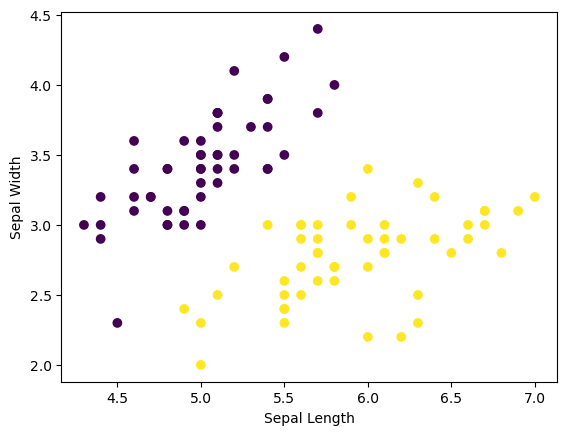

In [2]:
## Para este ejemplo: vamos a simplificar el problema. En vez de 3 categorias tendremos 2:
##  0 – setosa   1 – versi-color

# Vamos a graficar como se ven estos dos grupos usando solo las features de los sepalos 

iris_data   = iris_data[0:100]
iris_target = iris_target[0:100] 
import matplotlib.pyplot as plt
plt.scatter(iris_data[:,0],iris_data[:,1], c=iris_target)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")


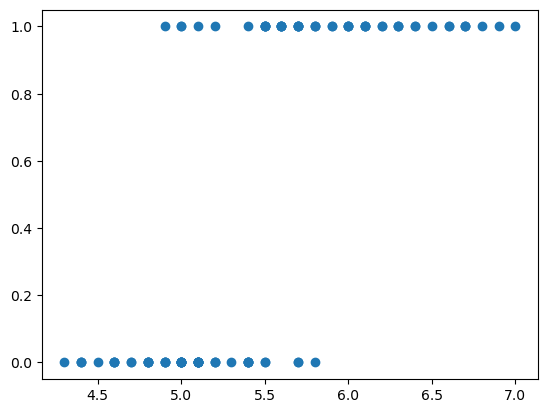

In [3]:
## Para simplificar aun más usaremos solo el largo del sepalo para predecir: 
plt.scatter(iris_data[:,0], iris_target)
## Está grafica se parece mucho a una función logistica

* Si podemos dibujar lo siguiente podemos clasificar que flor es versicolor y cual es setosa 
![alternative text](imagenes/logistic_regression.png)

### De donde viene la regresión logística:

De una función `logit` ¿Qué hace hace la función logit? Vamos a usar como ejemplo tirar un dado de 6 caras

¿Cuál es la probabilidad de que saquemos un cuatro?

$P_4 = \frac{Resultado \quad de \quad interes}{Opciones\quad posibles} = \frac{1}{6}$

¿Cuáles son los odds de sacar un 4?

$Odds_4 = \frac{probabilidad \quad de \quad sacar \quad un \quad 4}{probabilidad \quad de \quad todo \quad menos \quad 4} = \frac{P_4}{1 - P_4} = \frac{1/6}{5/6} = \frac{1}{5} = 0.2$   

¿Cuál es el logaritmo de los odds?

$log(odds) = log(\frac{P}{1-P})$

La regresión logistica, es una regresión lineal donde la variable dependiente es el log de los odds:

$log(\frac{P}{1-P}) = m + a_1X_1 + a_2X_2 + a_3X_3 + ...$

¿Cómo se ve graficamente $log(\frac{P}{1-P})$?

/var/folders/bl/8nlz54wj6vz1h95x_pcnxjc40000gn/T/ipykernel_82152/3264271668.py:4: RuntimeWarning: divide by zero encountered in log
  y = np.log (x/(1-x) )


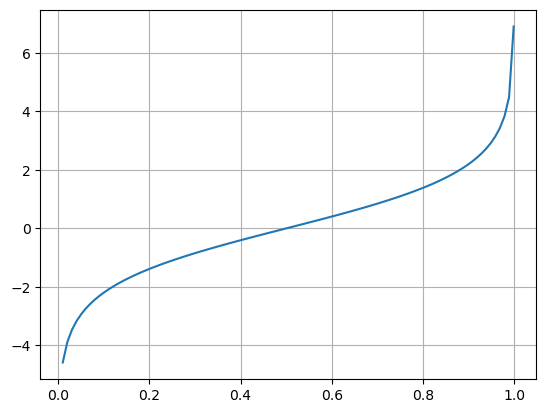

In [4]:
import numpy as np
 
x = np.linspace (0, 0.999, num=100)
y = np.log (x/(1-x) )

plt.plot(x,y)
plt.grid()

Esta es la curva de regresión logistica. Mapea un valor entre (0 y 1) a un número entre  ( -∞ to +∞ ). 
Sin embargo no queremos una variable continua sino una clasificación 0 o 1. 

Normalmente usaremos como threshold: 
    $p >= 0.5$ categoria 1
    $p < 0.5$ categoria 2

Para calcular estas probabilidades, necesitamos calcular la función inversa de una función logit. 

#### Función sigmoid 

La inversa de un logit es la función sigmoid. Tranforma un valor entre ( -∞ to +∞ ) a un valor entre 0 y 1. 

$$sigmoid_x = \frac{1}{1 + \exp^{-x}}$$



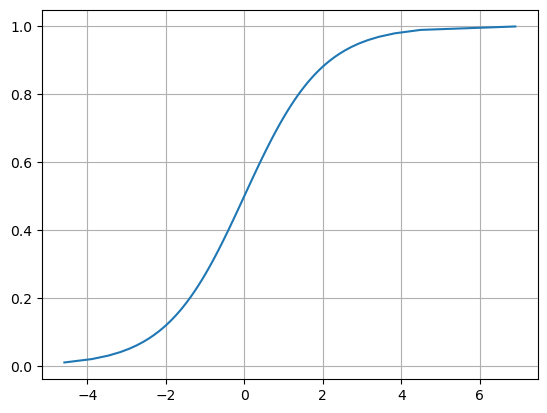

In [5]:
from scipy.special import expit
 
x_new = y
y_new = expit (x_new)
 
plt.plot(x_new,y_new)
plt.grid()

### Implementación usando `sklearn`

In [6]:
# Cargamos las librerias necesarias
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Partimos nuestros datos en train y test 
X_train, X_test, y_train, y_test = train_test_split (iris_data[:,0], iris_target)

# Definimos el modelo que vamos a usar: si no pongo parametros se usaron los que estan por default:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
regresion_logistica = linear_model.LogisticRegression()

# Ajustamos el modelo usando fit: 
regresion_logistica.fit(X_train.reshape(-1,1), y_train)

# Predecimos en nuestro test set
y_predict = regresion_logistica.predict(X_test.reshape(-1,1))


### Evalución:

* Accuracy 
* Matriz de confusión
* ROC Curve
* AUC

In [9]:
# Evaluamos nuestro modelo: accuracy
print ( "accuracy score = ",accuracy_score(y_test,y_predict) )

accuracy score =  0.88


In [10]:
# Evaluamos nuestro modelo: matriz de confusión
cm = confusion_matrix(y_test, y_predict)
print(cm)
tp = float(cm[0,0]) / float(cm[0,0] + cm[1,0])
fp = float(cm[1,0]) / float(cm[0,0] + cm[1,0])
tn = float(cm[0,1]) / float(cm[0,1] + cm[1,1])
fn = float(cm[1,1]) / float(cm[1,1] + cm[0,1])
print ("True Positive = ", tp)
print ("False Positive = ", fp)
print ("True Negative = ", tn)
print ("False Negative = ", fn)

[[15  1]
 [ 2  7]]
True Positive =  0.8823529411764706
False Positive =  0.11764705882352941
True Negative =  0.125
False Negative =  0.875


Text(0.3, 0.8, 'ROC Curve')

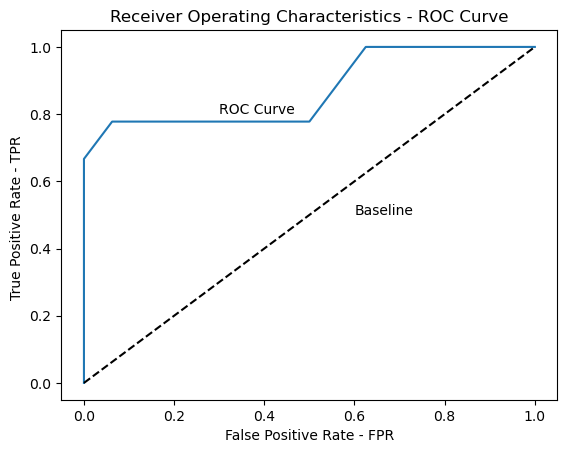

In [29]:
# ROC curve
from sklearn.metrics import roc_curve, auc, roc_auc_score

probabilities = regresion_logistica.predict_proba(X_test.reshape(-1,1))[:,1]
roc_auc_score(y_test, probabilities)
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],color="black",linestyle="--")
 
plt.xlabel("False Positive Rate - FPR")
plt.ylabel("True Positive Rate - TPR ")
plt.title("Receiver Operating Characteristics - ROC Curve")
plt.text(0.6,0.5,"Baseline")
plt.text(0.3,0.8,"ROC Curve")

In [31]:
# AUC: Area debajo de la ROC curve
roc_auc_score(y_test, probabilities)

0.8715277777777779

## Naive Bayes

¿Qué es Naive Bayes?
* modelo de clasificación probabilística básico inspirado en el teorema de Bayes
* teorema de Bayes 

$$P(A|B) = \frac{P(A|B)P(A)}{P(B)}$$

Donde: 
* A y B son dos eventos
* $P(A|B)$ es la probabilidad del evento A dado que el evento B paso
* $P(B|A)$ es la probabilidad del evento B dado que el evento A paso
* P(A) la probabilidad de A
* P(B) la probabilidad de B
    
Podemos usar el teorema de Bayes para generar el siguiente modelo de clasificación:
    $$P(y|X) = \frac{P(X|y)P(y)}{P(X)}$$

Donde:
* $X = x_1,x_2,...,x_N$ es una lista de predictores independiente
* y es la label 

Características del clasificacdor naive Bayes:
* Asume que todos los predictores contribuyen de manera igual e independiente a la selección de la label
* A pesar del supuesto de independencia, que casi nunca se cumple, el modelo produce resultados satisfactorios en la mayoría de los casos


### ¿Cómo funciona el algoritmo?

Vamos a usar un ejemplo muy sencillo: 

Nuestra label va a ser si jugamos afuera o no y tenemos una unica feature que nos informa del clima. 

| Clima |  Jugamos|
| --- | ---|
| soleado | No |
| nublado | Si |
| lluvioso | Si |
| soleado | Si |
| soleado | Si |
| nublado | Si |
| lluvioso | No |
| lluvioso | No |
| soleado | Si |
| lluvioso | Si |
| soleado | No |
| nublado | Si |
| nublado | Si |
| lluvioso | No |
    
    
Convertimos esto en una tabla de frecuencias: 

| Clima   | Si | No |
| ---     | -- | -- |
| Nublado | 4  | 0  |
| LLuvioso| 2  | 3  |
| Soleado | 3  | 2  |
| Total   | 9  | 5  |


Creamos una tabla de probabilidad: 

| Clima   | Si | No |   |    |
| ---     | -- | -- |-- | -- |
| Nublado | 4  | 0  |4/14| 0.29 |
| LLuvioso| 2  | 3  |5/14| 0.36 |
| Soleado | 3  | 2  |5/14| 0.36 |
| Total   | 9  | 5  |
|         |9/14|5/14|
|         |0.64|0.36|


Acá vemos que la probabilida de salir a jugar es 0.64 y de no salir es 0.36, la probabilidad de un día 
lluvioso es 0.36, la de un día soleado 0.36 y la de un día nublado 0.29

Usamos el teorema de Bayes: 

$P(Si|Soleado) = \frac{P(Soleado|Si)P(Si)}{P(Soleado)} = \frac{3/9*0.64}{0.36} = 0.60$

Naive Bayes hace algo muy parecido a esto usando más features!

In [34]:
import pandas as pd

cancer = pd.read_csv("../data/cancer.csv")
cancer.head()
cancer.info()
# quitar las variables q estorban 
cancer = cancer.drop(["id", "Unnamed: 32"], axis = 1)
## Nuestra variable de interes es:
cancer.diagnosis.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

B    357
M    212
Name: diagnosis, dtype: int64

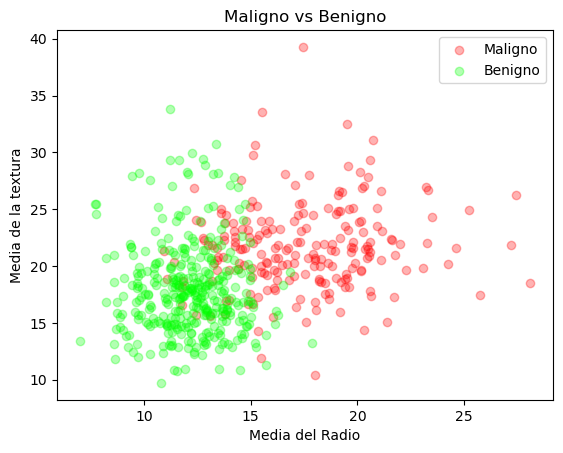

In [35]:
# Como se ve esta variable graficamente: 
plt.title("Maligno vs Benigno")
plt.xlabel("Media del Radio")
plt.ylabel("Media de la textura")
plt.scatter(cancer.query("diagnosis == 'M'").radius_mean,
            cancer.query("diagnosis == 'M'").texture_mean, color = "red",
            label = "Maligno", alpha = 0.3)
plt.scatter(cancer.query("diagnosis == 'B'").radius_mean, 
            cancer.query("diagnosis == 'B'").texture_mean, color = "lime", label = "Benigno", alpha = 0.3)
plt.legend()
plt.show()

In [36]:
# mini Pre-procesamiento de los datos 
cancer.diagnosis = [1 if dia == 'M' else 0 for dia in cancer.diagnosis]

In [37]:
from sklearn.naive_bayes import GaussianNB

X = cancer.drop(["diagnosis"], axis = 1)
y = cancer.diagnosis.values

## Dividimos nuestros datos en test y train: 
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 12)

# definimops el modelo y lo entrenamos
nb = GaussianNB()
nb.fit(x_train, y_train)

# predecimos: 
y_predict = nb.predict(x_test)

In [38]:
# ¿Cómo lo hizo el modelo? 
print("Naive Bayes score: ",nb.score(x_test, y_test))

# ¿Nos funciona bien está metrica en este caso?
cm_nb = confusion_matrix(y_test, y_predict)

Naive Bayes score:  0.9300699300699301


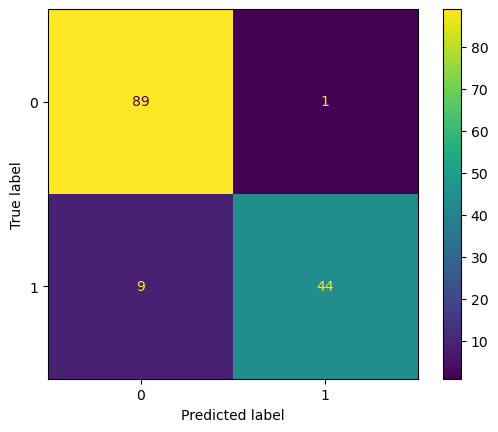

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_nb_dis = ConfusionMatrixDisplay(confusion_matrix = cm_nb,
                               display_labels = nb.classes_)
cm_nb_dis.plot()

Acá tal vez otra medida tenga más sentido no?

En este ejemplo: 
* Precision: la proporción de las predicciones del modelo cuando si hubo cancer 
* Recall: la proporción de todos los casos de cancer que el modelo si pudo predecir
    
$P = \frac{TP}{TP + FP}$

$R = \frac{TP}{TP + FN}$

En este caso un modelo que prediga que todo el mundo tenga cancer va a tener recall de 100%
pero precisión de 1%.

¿Cuál es el problema con un modelo así?

In [40]:
## Acá tal vez otra medida tenga más sentido no?
# Calculamos Recall y F1 de nuestros modelo: 
from sklearn.metrics import recall_score, f1_score
print("Recall score: " + str(recall_score(y_test,y_predict)))
print("F1: " + str(f1_score(y_test, y_predict)))

Recall score: 0.8301886792452831
F1: 0.8979591836734695
